# Cyanobacteria bloom model, Lake Greifensee

I model cyanobacteria blooms in Lake Greifensee from the lake's own physical conditions plus the season. The data comes from EAWAG's automated monitoring platform (daily values, 2020-2021). A "bloom" day is defined as phycocyanin above its 75th percentile, set when building the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

## 1. Loading the data

The prepared dataset, one row per day, with the target and the features.

In [2]:
df = pd.read_csv("../data/processed/dataset.csv", parse_dates=["date"])
df

,date,mean_phy,target,mean_temp,mean_schmidt,mean_par,windspeed_mean,precipitation_tot,month_sin,month_cos
0,2020-07-01,4.796831,0,19.937151,1104.423806,46.780634,2.2,14.0,-5.000000e-01,-0.866025
1,2020-07-02,5.124668,0,19.908480,1113.749434,30.785148,2.0,1.5,-5.000000e-01,-0.866025
2,2020-07-03,5.369718,0,20.055217,1088.947094,10.567077,1.2,0.1,-5.000000e-01,-0.866025
3,2020-07-04,5.676056,0,19.752676,1054.977100,32.419718,1.6,0.0,-5.000000e-01,-0.866025
4,2020-07-05,5.465845,0,19.773824,1064.755147,37.176408,2.4,0.0,-5.000000e-01,-0.866025
...,...,...,...,...,...,...,...,...,...,...
501,2021-12-27,0.365493,0,5.832215,0.370027,-1.668662,1.2,4.8,-2.449294e-16,1.000000
502,2021-12-28,0.220775,0,5.817972,0.028860,-2.277113,5.6,7.3,-2.449294e-16,1.000000
503,2021-12-29,0.165141,0,5.816250,0.300706,-3.384155,4.8,8.3,-2.449294e-16,1.000000
504,2021-12-30,0.602113,0,5.897768,1.447501,-1.472535,1.9,0.0,-2.449294e-16,1.000000


## 2. Exploring the data

First the class balance, then how the conditions differ between bloom and non-bloom days.

In [3]:
df.groupby("target").count()

,date,mean_phy,mean_temp,mean_schmidt,mean_par,windspeed_mean,precipitation_tot,month_sin,month_cos
target,,,,,,,,,
0,379,379,379,379,379,379,379,379,379
1,127,127,127,127,127,127,127,127,127


In [4]:
df.groupby("target")[["mean_temp", "mean_schmidt", "mean_par", "windspeed_mean"]].mean()

,mean_temp,mean_schmidt,mean_par,windspeed_mean
target,,,,
0,14.144389,556.072294,9.152513,1.946966
1,11.207590,297.144333,4.245481,1.703937


Bloom days are colder, less stratified (lower Schmidt) and get less light than non-bloom days. This looks backwards from the usual "warm summer means a bloom" idea, but it's expected here: the dominant cyanobacterium in deep peri-alpine lakes (Planktothrix) lives in deeper layers and gets mixed up to the surface during the colder, less stratified periods. So the model should learn that colder, mixed conditions go with blooms.

## 3. Features and target

I keep only the physical and meteorological drivers plus the season. I leave out mean_phy, chlorophyll and the other plankton columns since they basically are the answer, which would be leakage.

In [5]:
FEATURES = ["mean_temp", "mean_schmidt", "mean_par",
            "windspeed_mean", "precipitation_tot", "month_sin", "month_cos"]

X = df[FEATURES]
y = df["target"]

## 4. Models
Logistic Regression to see the trend of the model.

Random Forest with balanced class weights (about a quarter of the days are blooms), evaluated with 5-fold stratified cross-validation.

### 4.1 Logistic Regression
Logistic regression values ​​need to be scaled because their range of values ​​varies considerably.

In [6]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [7]:
auc_lr = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
print("Logistic Regression ROC-AUC :", auc_lr.mean().round(3), "±", auc_lr.std().round(3))

Logistic Regression ROC-AUC : 0.68 ± 0.03


ROC-AUC is 0.68. Since 0.5 means the model has no predictive capacities, it is still an honest result but not the best neither.

### 4.2 Random Forest

In [8]:
clf = RandomForestClassifier(class_weight="balanced", random_state=42)

In [9]:
df["proba_pred"] = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]

auc_rf = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
ap_rf  = cross_val_score(clf, X, y, cv=cv, scoring="average_precision")
print("Random Forest ROC-AUC :", auc_rf.mean().round(3), "±", auc_rf.std().round(3))
print("Random Forest PR-AUC :", ap_rf.mean().round(3), "±", ap_rf.std().round(3))

Random Forest ROC-AUC : 0.902 ± 0.029
Random Forest PR-AUC : 0.715 ± 0.062


ROC-AUC is 0.90 and PR-AUC is 0.72, well above the 0.25 base rate, so the model predicts blooms quite well. The cross-validation keeps this honest, since each fold is tested on data it wasn't trained on. It is also well above the Logistic Regression result, so the Random Forest will be kept as the main model for this research.

In [10]:
clf.fit(X, y)
imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(imp)

mean_schmidt         0.224862
mean_temp            0.220569
mean_par             0.186943
month_cos            0.123210
windspeed_mean       0.101968
month_sin            0.087993
precipitation_tot    0.054456
dtype: float64


Schmidt is the most used variable, then water temperature and light. The importances are fairly spread out, so the model isn't just reading off the calendar month, it really uses the environmental conditions.

In [11]:
pred = cross_val_predict(clf, X, y, cv=cv)
print(confusion_matrix(y, pred))
print(classification_report(y, pred))

[[313  66]
 [ 27 100]]
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       379
           1       0.60      0.79      0.68       127

    accuracy                           0.82       506
   macro avg       0.76      0.81      0.78       506
weighted avg       0.84      0.82      0.82       506



The model catches 79% of the blooms (recall) with a precision of 0.60. For a warning use case, missing a bloom is worse than a false alarm, so favouring recall is the right call.

## 5. Probability over time

Blooms predicted probability day by day, smoothed over 14 days. The seasonal cycles are clear: peaks in spring and autumn, lows in summer and deep winter.

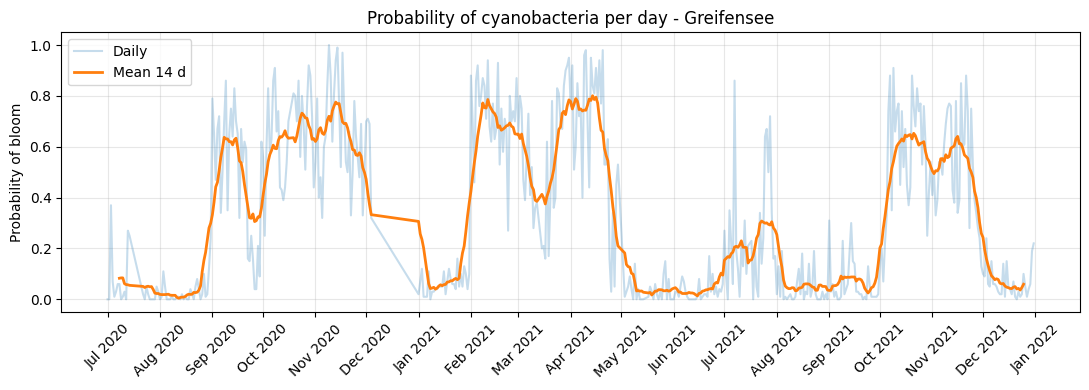

In [15]:
df = df.sort_values("date")

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(df["date"], df["proba_pred"], alpha=0.25, label="Daily")
ax.plot(df["date"], df["proba_pred"].rolling(14, center=True).mean(),
        lw=2, label="Mean 14 d")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

ax.set_ylabel("Probability of bloom")
ax.set_title("Probability of cyanobacteria per day - Greifensee")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/cyano_per_day_greifensee.svg")
plt.show()

## 6. Predicted vs observed by month

Average predicted probability against the observed bloom rate for each month, to check the model tracks reality.

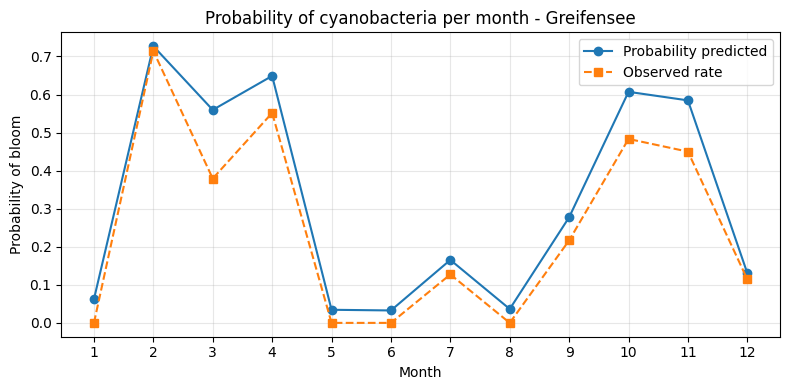

In [14]:
df["proba_pred"] = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]

grp = df.groupby(df["date"].dt.month)
proba_mois = grp["proba_pred"].mean()
taux_obs = grp["target"].mean()

plt.figure(figsize=(8, 4))
plt.plot(proba_mois.index, proba_mois.values, marker="o", label="Probability predicted")
plt.plot(taux_obs.index,   taux_obs.values,   marker="s", ls="--", label="Observed rate")
plt.xlabel("Month")
plt.ylabel("Probability of bloom")
plt.title("Probability of cyanobacteria per month - Greifensee")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/actual_vs_predicted.svg")
plt.show()

The two curves follow each other closely, so the model reproduces the seasonal pattern well. The predicted line sits a bit above the observed one because the balanced class weights push the probabilities up, so read the shape here rather than the exact level.